# 🕒 Cron Job Monitor - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/cron-monitor/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/cron-monitor/demo.ipynb)

> *"We don't know when batch jobs fail."*

A **dead-man's-switch** for scheduled work. Each job registers an expected
heartbeat interval and pings on every successful run. Miss the deadline
(`interval + grace`) and the job is flagged **overdue** - one alert per outage,
no spam.

**What we cover**
1. Register jobs + send heartbeats
2. Detect overdue jobs (deadline math)
3. Alert exactly once per outage
4. Recover on the next ping
5. Visualize a heartbeat timeline


## Step 1 - The monitor

Pure logic: every method takes `now` explicitly, so behavior is fully
deterministic and testable (no hidden wall-clock).


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, List, Optional

@dataclass
class Job:
    name: str
    interval_seconds: float
    grace_seconds: float = 60.0
    last_ping: Optional[float] = None
    last_alerted: Optional[float] = None
    def deadline(self) -> Optional[float]:
        return None if self.last_ping is None else self.last_ping + self.interval_seconds + self.grace_seconds
    def state(self, now: float) -> str:
        if self.last_ping is None:
            return "pending"
        return "overdue" if now > self.deadline() else "healthy"

@dataclass
class Monitor:
    jobs: Dict[str, Job] = field(default_factory=dict)
    def register(self, name, interval_seconds, grace_seconds=60.0):
        self.jobs[name] = Job(name, interval_seconds, grace_seconds)
        return self.jobs[name]
    def ping(self, name, now):
        j = self.jobs[name]; j.last_ping = now; j.last_alerted = None; return j
    def overdue(self, now):
        return [j for j in self.jobs.values() if j.state(now) == "overdue"]
    def alerts_to_fire(self, now):
        out = []
        for j in self.overdue(now):
            if j.last_alerted is None or (j.last_ping is not None and j.last_alerted < j.last_ping):
                j.last_alerted = now; out.append(j)
        return out

mon = Monitor()
mon.register("nightly_etl", interval_seconds=100, grace_seconds=10)
mon.register("hourly_sync", interval_seconds=50, grace_seconds=5)
print("Registered:", list(mon.jobs))

Registered: ['nightly_etl', 'hourly_sync']


## Step 2 - Heartbeats, then a missed deadline

Both jobs ping at t=1000. By t=1060, `hourly_sync` (deadline 1055) is **overdue**;
`nightly_etl` (deadline 1110) is still healthy.


In [2]:
t0 = 1000.0
mon.ping("nightly_etl", now=t0)
mon.ping("hourly_sync", now=t0)

now = t0 + 60
for j in mon.jobs.values():
    print(f"{j.name:14s} deadline={j.deadline():.0f}  state={j.state(now)}")

nightly_etl    deadline=1110  state=healthy
hourly_sync    deadline=1055  state=overdue


## Step 3 - Alert once per outage

`alerts_to_fire` returns overdue jobs that haven't been alerted since their last
ping - so a multi-hour outage pages you **once**, not every check cycle.


In [3]:
first = mon.alerts_to_fire(now)
second = mon.alerts_to_fire(now + 30)   # still overdue, but already alerted
print("first check fires :", [j.name for j in first])
print("second check fires:", [j.name for j in second])

first check fires : ['hourly_sync']
second check fires: []


## Step 4 - Recovery clears the alert

When the job finally runs again, its ping resets state to healthy and re-arms the
alert for any future outage.


In [4]:
mon.ping("hourly_sync", now=now + 40)
print("after recovery ping:", mon.jobs["hourly_sync"].state(now + 40))

after recovery ping: healthy


## Step 5 - Heartbeat timeline, visualized

Green dots are successful pings; the red span is the outage window where the job
blew past its deadline.


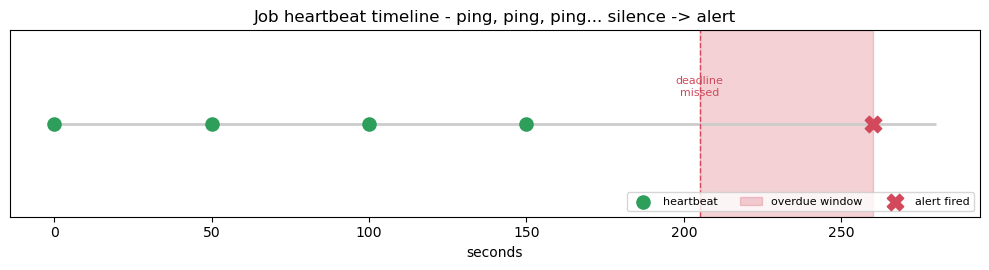

In [5]:
import matplotlib.pyplot as plt

# Simulate a job that pings every 50s, then goes dark.
interval, grace = 50, 5
pings = [0, 50, 100, 150]          # then silence
gap_start = pings[-1]
deadline = gap_start + interval + grace
outage_detected = 260

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.hlines(1, 0, outage_detected + 20, color="#ccc", lw=2)
ax.scatter(pings, [1]*len(pings), color="#2e9e5b", s=90, zorder=3, label="heartbeat")
ax.axvspan(deadline, outage_detected, color="#d1495b", alpha=0.25, label="overdue window")
ax.axvline(deadline, color="#d1495b", ls="--", lw=1)
ax.text(deadline, 1.15, "deadline\nmissed", color="#d1495b", ha="center", fontsize=8)
ax.scatter([outage_detected], [1], marker="X", color="#d1495b", s=140, zorder=4, label="alert fired")
ax.set_ylim(0.5, 1.5); ax.set_yticks([]); ax.set_xlabel("seconds")
ax.set_title("Job heartbeat timeline - ping, ping, ping... silence -> alert")
ax.legend(loc="lower right", ncol=3, fontsize=8)
plt.tight_layout(); plt.savefig("timeline.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary

- A job is **overdue** when `now > last_ping + interval + grace`.
- Alerts fire **once per outage** and re-arm only after a recovery ping.
- Email is **dry-run by default** - set `SMTP_HOST` (+ creds) to send for real.

This is the engine behind the FastAPI service in `api.py` (with a `/check`
endpoint a scheduler hits on an interval).


---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run the service:**
```bash
pip install -r requirements.txt
uvicorn api:app --reload
# register a job, then have it POST /ping/<name> on every run
# point a scheduler at POST /check to evaluate + alert
```
